In [ ]:
from intervention.paths import DATASETS_DIR, STATES_DIR, resolve_weights
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from typing import Optional
from intervention.state_analysis.states_extract import StateExtractor, StatesDataset
import os, sys

from intervention.utils import seed_everything, set_device
from intervention.models.swp_model import get_model
from intervention.paths import get_phoneme_to_id
from ast import literal_eval
from sklearn.decomposition import PCA
from typing import Optional
import plotly.graph_objects as go
import plotly.colors as pc
from sklearn.preprocessing import StandardScaler

In [ ]:
#  Setup
seed_everything(42)
device = set_device()
model_name = "Ua_LSTM_h128_l1_v42_d0.0_t0.0_s1"
weights_path = resolve_weights("resources/weights/1024_75.pth")

model = get_model(model_name)
model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
model.to(device)
model.eval()
phoneme_to_id = get_phoneme_to_id()
id_to_phoneme = {v: k for k, v in phoneme_to_id.items()}
converters = {"Word": str, "Phonemes": literal_eval, "No_Stress": literal_eval}

extractor = StateExtractor(model, phoneme_to_id, device)
# Load phoneme categories
phoneme_data = pd.read_csv(DATASETS_DIR / "phonemes.csv")
vowels = phoneme_data["Phoneme"][phoneme_data["Type"] == "V"].tolist()
consonants = phoneme_data["Phoneme"][phoneme_data["Type"] == "C"].tolist()
# load datasets (StatesDataset)
train_ds = StatesDataset.load(str(STATES_DIR / "train_states")) # train dataset with 30k real words
test_ds = StatesDataset.load(str(STATES_DIR / "test_states")) # 1200 words real and pseudo words

wfe = pd.read_csv(DATASETS_DIR / "wfe_with_repetition_result.csv")

In [7]:
def _to_polar(pca_2d):
    """Convert 2D Cartesian to polar coordinates."""
    polar = np.zeros((len(pca_2d), 2))
    for i in range(len(pca_2d)):
        x, y = pca_2d[i, 0], -pca_2d[i, 1]
        polar[i, 0] = np.linalg.norm([x, y]) # radius 
        polar[i, 1] = np.arctan2(y, x) # angle
    return polar


def _get_edge_colorline(from_type, to_type):
    """Get color and linestyle based on phoneme type transition."""
    transitions = {
        ('C', 'C'): ('orange', '--'),
        ('C', 'V'): ('purple', '-'),
        ('V', 'C'): ('green', '--'),
        ('V', 'V'): ('blue', '-'),
        ('C', 'EOS'): ('gray', ':'),
        ('V', 'EOS'): ('gray', ':'),
    }
    return transitions.get((from_type, to_type), ('black', '-'))


def _get_color_fn(meta, word_df, color_by):
    """Get color function and legend values for a given color_by column."""
    if color_by == "phoneme_type":
        color_dict = {'V': 'blue', 'C': 'orange', 'EOS': 'gray'}
        return lambda v: color_dict.get(v, 'black'), ['V', 'C', 'EOS'], color_dict
    
    vals = meta[color_by].unique() if color_by in meta.columns else word_df[color_by].unique()
    is_numeric = pd.api.types.is_numeric_dtype(meta[color_by]) if color_by in meta.columns else False
    
    if is_numeric:
        return lambda v: plt.cm.rainbow(v / vals.max()), None, None
    
    cmap = plt.cm.Set3(np.linspace(0, 1, len(vals)))
    color_dict = {v: cmap[i] for i, v in enumerate(vals)}
    return lambda v: color_dict[v], vals, color_dict


def plot_words_trajectories(pca_2d, meta, word_df, color_by, title, drop_eos=False, save_path=None, show_phonemes=False, edge_labels=False):
    """Plot word trajectories in polar space.
    
    Args:
        pca_2d: 2D PCA embeddings
        meta: metadata DataFrame
        word_df: word properties DataFrame
        color_by: column to color by
        title: plot title
        drop_eos: skip EOS if True
        save_path: save figure to path
        show_phonemes: show phoneme labels on nodes
        edge_labels: use edge-based coloring/linestyle
    """
    meta = meta.reset_index(drop=True)
    polar = _to_polar(pca_2d)
    color_fn, legend_vals, color_dict = _get_color_fn(meta, word_df, color_by)
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'})
    
    for word in meta["word"].unique():
        indices = np.where(meta["word"] == word)[0]
        if drop_eos is True:
            indices = np.array([i for i in indices if meta.iloc[i]["phoneme"] != '<EOS>'])
        
        # if len(indices) < 2:
        #     continue
        
        # Get word metadata
        phoneme_types = meta.iloc[indices]["phoneme_type"].values
        
        r = polar[indices, 0]
        theta = polar[indices, 1]
        
        # Determine colors and linestyles
        if not edge_labels:
            # Node-based coloring
            if color_by in meta.columns:
                colors = [color_fn(meta.iloc[i][color_by]) for i in indices]
            else:
                # color_by is in word_df
                row = word_df[word_df["Word"] == word]
                if not row.empty:
                    color = color_fn(row[color_by].values[0])
                    colors = [color] * len(r)
                else:
                    colors = ['blue'] * len(r)
            linestyles = ['-'] * len(colors)
        else:
            # Edge-based coloring
            colors = []
            linestyles = []
            for i in range(len(phoneme_types) - 1):
                color, linestyle = _get_edge_colorline(phoneme_types[i], phoneme_types[i+1])
                colors.append(color)
                linestyles.append(linestyle)
        
        # Plot trajectory
        for i in range(len(r) - 1):
            # linestyle = '--' if phoneme_types[i] == 'C' else '-'
            alpha = 0.3 + 0.7 * i / max(len(r) - 1, 1)
            ax.plot(theta[i:i+2], r[i:i+2], linestyle=linestyles[i], color=colors[i+1], lw=2, alpha=alpha)
        
        # Mark start node
        ax.scatter(theta[0], r[0], marker='o', s=5, color='blue', zorder=5)
        
        # Optional: show phoneme labels
        if show_phonemes:

            phonemes = meta.iloc[indices]["phoneme"].values
            for i in range(len(r)):
                ax.text(theta[i], r[i], phonemes[i][:2], fontsize=7, ha='center', va='center')
    
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    ax.set_rticks([0, 10])
    ax.set_title(title)
    
    # Legend
    if legend_vals is not None and not edge_labels:
        handles = [plt.Line2D([0], [0], color=color_dict[v], lw=4) for v in legend_vals]
        ax.legend(handles, legend_vals, title=color_by, loc='upper right', bbox_to_anchor=(1.1, 1.1), fontsize=9)
    elif edge_labels:
        # Edge-based legend
        transitions = [('C→C', 'orange', '--'), ('C→V', 'purple', '-'), ('V→C', 'green', '--'), 
                      ('V→V', 'blue', '-'), ('C→EOS', 'gray', ':'), ('V→EOS', 'gray', ':')]
        handles = [plt.Line2D([0], [0], color=t[1], linestyle=t[2], lw=4) for t in transitions]
        labels = [t[0] for t in transitions]
        ax.legend(handles, labels, title='transitions', loc='upper right', bbox_to_anchor=(1.1, 1.1), fontsize=9)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

In [8]:
pca = PCA(n_components=2)
h_pca = pca.fit_transform(StandardScaler().fit_transform(test_ds.h))

pca = PCA(n_components=2)
c_pca = pca.fit_transform(StandardScaler().fit_transform(test_ds.c))

pca = PCA(n_components=2)
state_pca = pca.fit_transform(StandardScaler().fit_transform(test_ds.state))

pca = PCA(n_components=2)
delta_state_pca = pca.fit_transform(StandardScaler().fit_transform(test_ds.delta_state))

pca = PCA(n_components=2)
delta_h_pca = pca.fit_transform(StandardScaler().fit_transform(test_ds.delta_h))

pca = PCA(n_components=2)
delta_c_pca = pca.fit_transform(StandardScaler().fit_transform(test_ds.delta_c))

In [207]:
for index, row in wfe[wfe["can_repeat"]==False].iterrows():
    print(row['Word'])
    print(row['No_Stress'])
    print(row['predicted_seq'])
    print()


superfluous
['S', 'UW', 'P', 'ER', 'F', 'L', 'W', 'AH', 'S']
['S', 'UW', 'P', 'F', 'ER', 'L', 'W', 'AH', 'S', '<EOS>']

vanderbilt
['V', 'AE', 'N', 'D', 'ER', 'B', 'IH', 'L', 'T']
['V', 'AE', 'N', 'D', 'ER', 'B', 'IH', 'L', '<EOS>', '<PAD>']

coallencite
['K', 'OW', 'AA', 'L', 'EH', 'N', 'S', 'AY', 'T']
['K', 'OW', 'AA', 'L', 'EH', 'N', 'S', 'T', 'AY', '<EOS>']

yesperest
['Y', 'EH', 'S', 'P', 'IH', 'R', 'EH', 'S', 'T']
['S', 'EH', 'P', 'Y', 'IH', 'R', 'EH', 'S', 'T', '<EOS>']

alrelopal
['AE', 'L', 'R', 'EH', 'L', 'AA', 'P', 'AH', 'L']
['AE', 'L', 'R', 'EH', 'L', 'AH', 'P', 'AA', 'L', '<EOS>']

honofecine
['HH', 'OW', 'N', 'OW', 'F', 'AH', 'S', 'IY', 'N']
['HH', 'OW', 'N', 'OW', 'F', 'AH', 'N', 'S', 'IY', '<EOS>']

reasoduct
['R', 'IY', 'AH', 'S', 'OW', 'D', 'AH', 'K', 'T']
['R', 'AH', 'S', 'IY', 'OW', 'K', 'D', 'AH', 'T', '<EOS>']

sigrusachy
['S', 'IY', 'G', 'R', 'UW', 'S', 'AH', 'CH', 'IY']
['S', 'IY', 'G', 'R', 'UW', 'CH', 'AH', 'S', 'IY', '<EOS>']

unledging
['AH', 'N', 'L', 'EH'

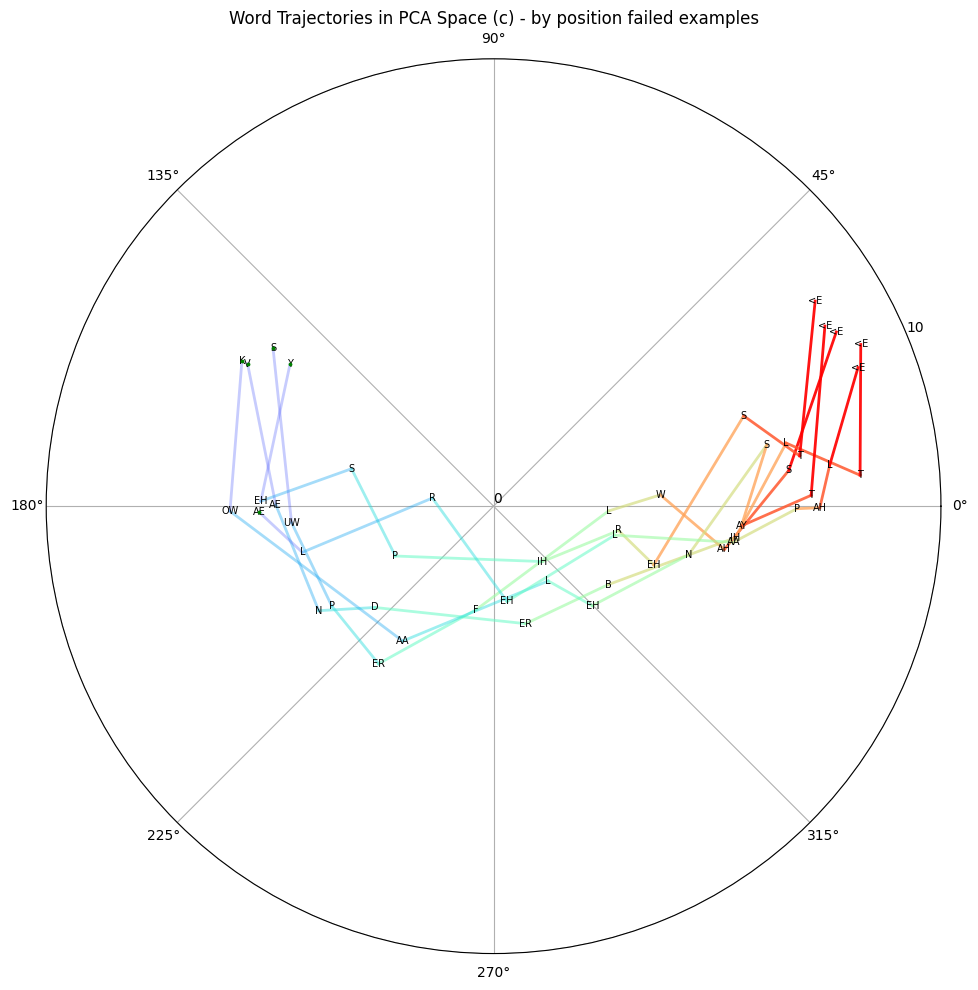

In [228]:
# for failed examples
failed = wfe[wfe["can_repeat"]==False][:5]
failed_meta = test_ds.metadata[test_ds.metadata["word"].isin(failed["Word"])]
failed_mask = test_ds.metadata["word"].isin(failed["Word"])
failed_pca = h_pca[failed_mask]
plot_words_trajectories(failed_pca, failed_meta, wfe, color_by="position",
                        show_phonemes=True,
                        title="Word Trajectories in PCA Space (c) - by position failed examples",
                        save_path="plots/word_trajectories/test_c_by_position_failed.png")


In [126]:
indices = np.where(test_ds.metadata["word"] == "bad")[0]
indices

array([4883, 4884, 4885, 4886])

In [ ]:
test_ds.metadata.iloc[4884]

seq_id          667
word            bad
position          1
phoneme          AE
phoneme_type      V
Name: 4884, dtype: object

In [218]:
word = 'super'
if word in train_ds.metadata["seq_condition"].values:
    print('y')

y


In [223]:
# rename seq_condition to word in metadata
train_ds.metadata.rename(columns={"Word": "word"}, inplace=True)

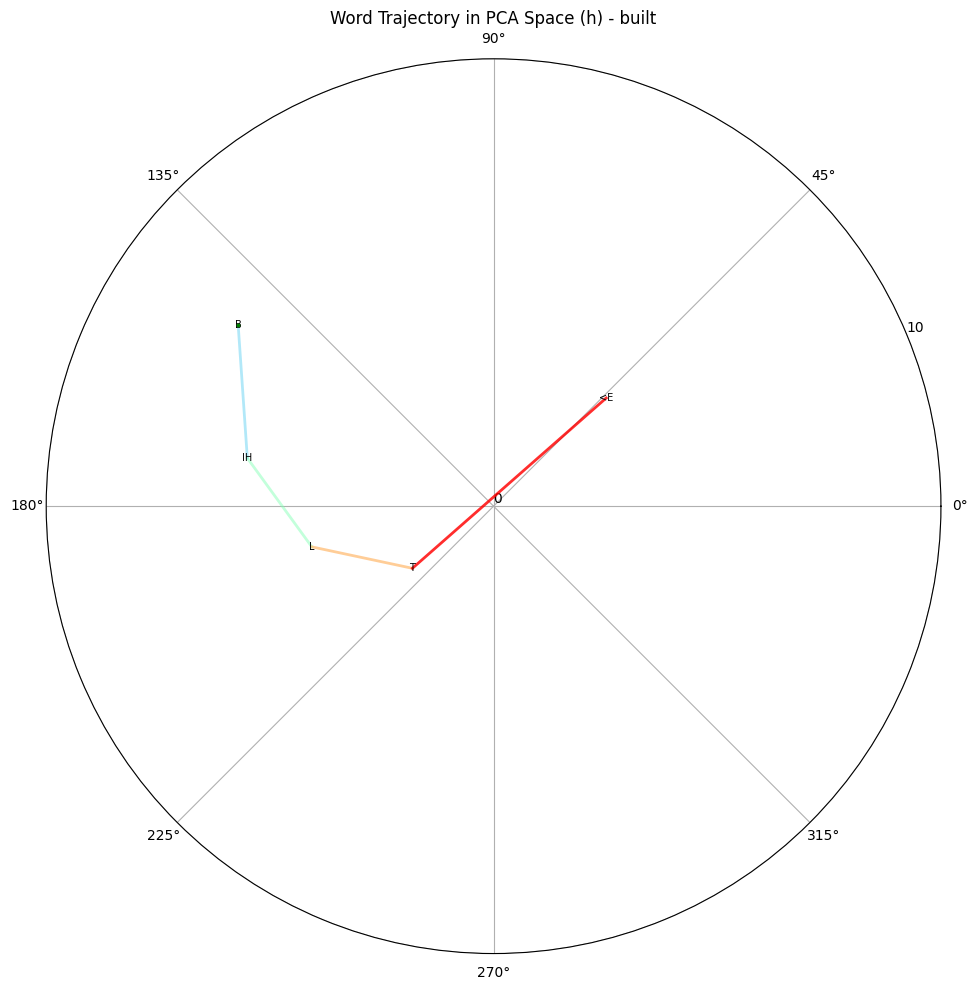

In [227]:
word = "built"
word_meta = train_ds.metadata[train_ds.metadata["word"] == word]
word_mask = train_ds.metadata["word"] == word
pca = PCA(n_components=2)
h_pca_train = pca.fit_transform(StandardScaler().fit_transform(train_ds.h))
word_pca = h_pca_train[word_mask]
plot_words_trajectories(word_pca, word_meta, wfe, color_by="position",
                        show_phonemes=True,
                        title=f"Word Trajectory in PCA Space (h) - {word}")

In [148]:
pca = PCA(n_components=2)
standardized_delta_state = StandardScaler().fit_transform(test_ds.h)
h_pca = pca.fit_transform(standardized_delta_state)

In [177]:
# random words from wfe
import random
random_words = random.sample(list(wfe["Word"].unique()), 4)
words_meta = test_ds.metadata[test_ds.metadata["word"].isin(random_words)]
words_mask = test_ds.metadata["word"].isin(random_words)


In [229]:
# 6 random words 3 real and 3 pseudo words
from sklearn.model_selection import train_test_split
examples = train_test_split(wfe, test_size=6, stratify=wfe["Lexicality"], random_state=42)
words = examples[1]["Word"].to_list()
words_meta = test_ds.metadata[test_ds.metadata["word"].isin(words)]
words_mask = test_ds.metadata["word"].isin(words)



In [194]:
examples[1][["Word", "Lexicality", "No_Stress", "predicted_seq"]]

,Word,Lexicality,No_Stress,predicted_seq
1148,huxice,pseudo,"['HH', 'AH', 'K', 'S', 'IH', 'K', 'S']",NaN
571,eels,real,"['IY', 'L', 'Z']",NaN
263,project,real,"['P', 'R', 'AA', 'JH', 'EH', 'K', 'T']",NaN
619,wear,real,"['W', 'EH', 'R']",NaN
902,opist,pseudo,"['OW', 'P', 'IH', 'S', 'T']",NaN
52,functional,real,"['F', 'AH', 'NG', 'K', 'SH', 'AH', 'N', 'AH', ...",NaN


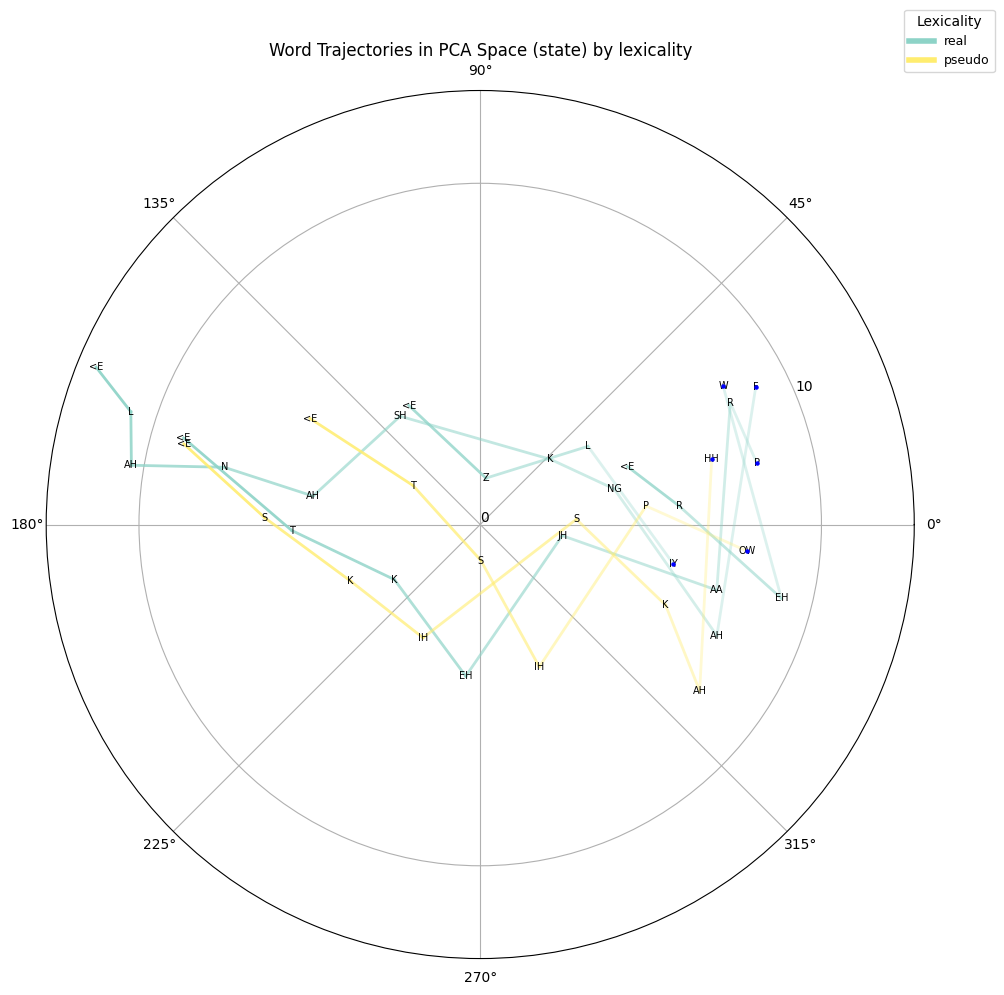

In [232]:
plot_words_trajectories(state_pca[words_mask], words_meta, wfe,color_by="Lexicality",
                        show_phonemes=True,
                        title="Word Trajectories in PCA Space (state) by lexicality")

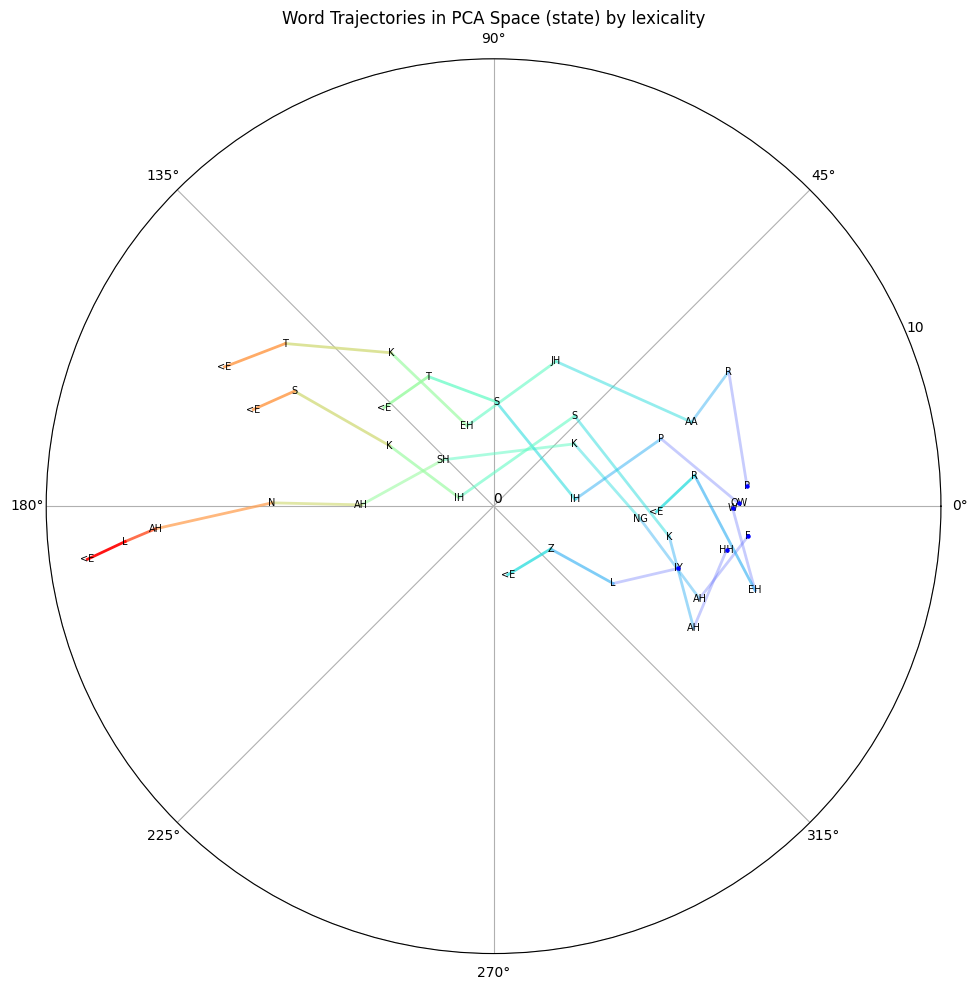

In [234]:
plot_words_trajectories(c_pca[words_mask], words_meta, wfe,color_by="position",
                        show_phonemes=True,
                        title="Word Trajectories in PCA Space (state) by lexicality")

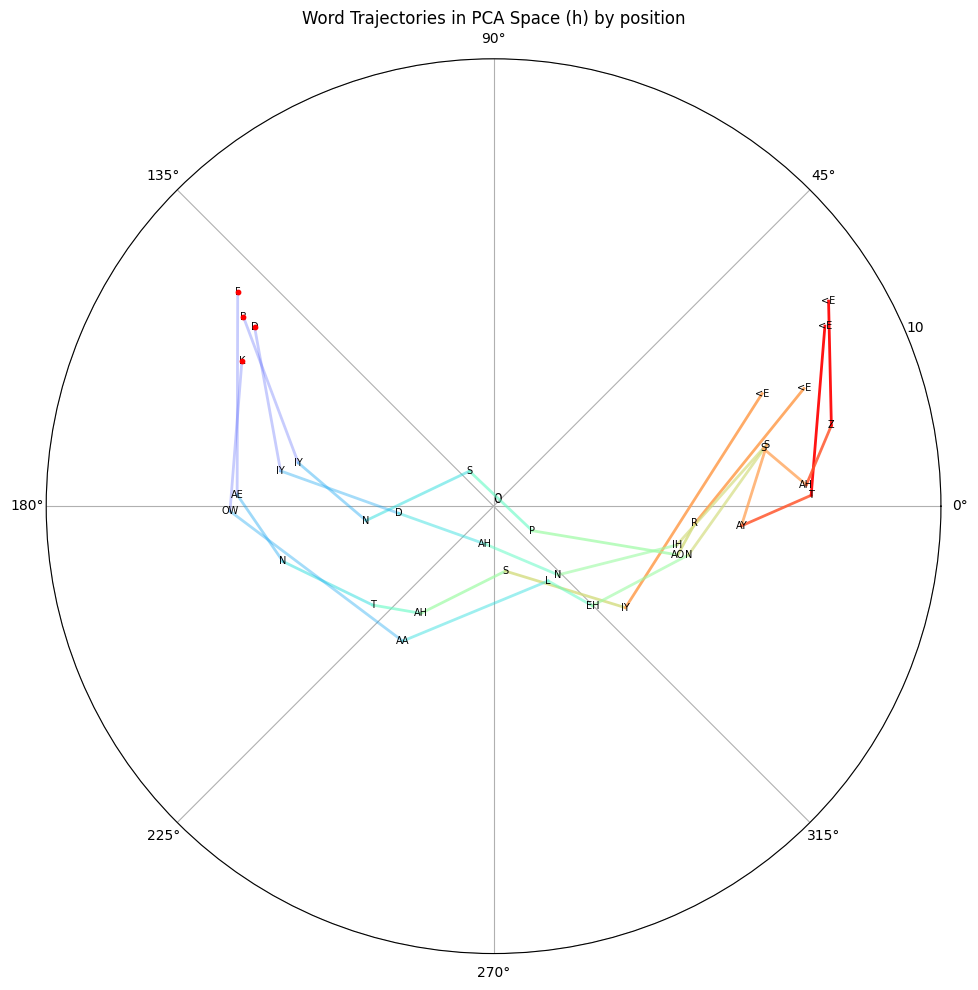

In [179]:
plot_words_trajectories(h_pca[words_mask], words_meta, wfe,color_by="position",
                        show_phonemes=True,
                        title="Word Trajectories in PCA Space (h) by position")

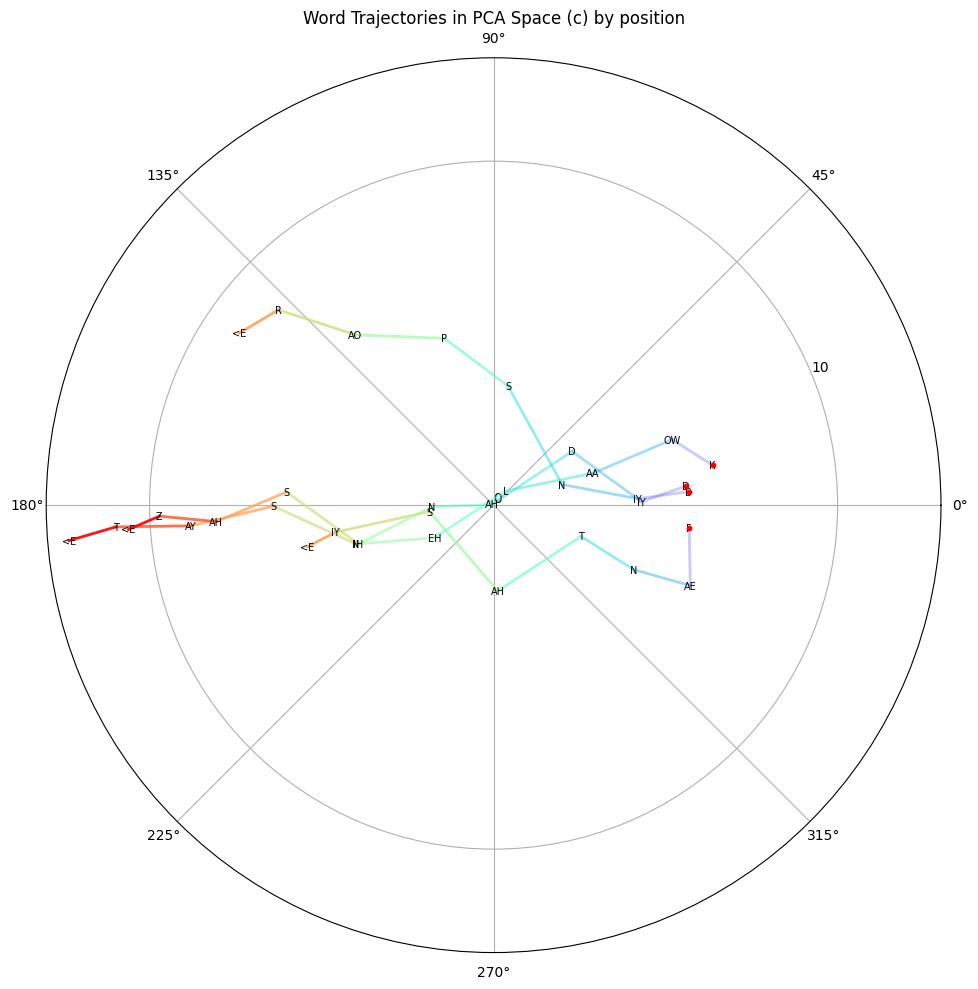

In [180]:
plot_words_trajectories(c_pca[words_mask], words_meta, wfe,color_by="position",
                        show_phonemes=True,
                        title="Word Trajectories in PCA Space (c) by position")

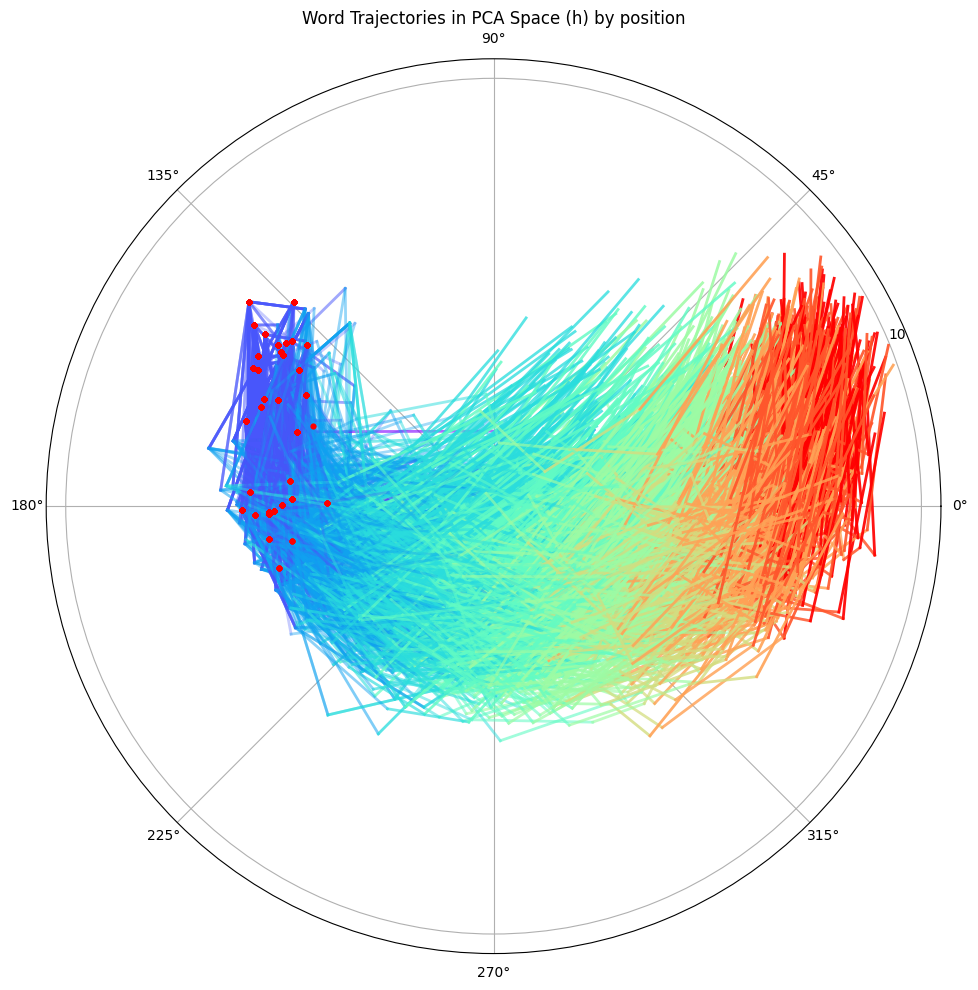

In [161]:
plot_words_trajectories(h_pca, test_ds.metadata, wfe,color_by="position",
                        # drop_eos=True,
                        title="Word Trajectories in PCA Space (h) by position",)
                        # save_path="plots/word_trajectories/test_h_by_position_drop_eos.png")

In [ ]:
def plot_words_trajectory_old(meta, words,all_2d, state_type="state", alpha_by_pos=True):

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'})
    colors_words = plt.cm.Set3(np.linspace(0, 1, len(words)))
    
    for w_idx, word in enumerate(words):
        word_mask = meta["word"] == word
        # SKIP if word not found
        if not word_mask.any():
            print(f"'{word}' not found.")
            continue
        
        embs_2d = all_2d[word_mask]

        positions = meta.loc[word_mask, "position"].values
        phonemes = meta.loc[word_mask, "phoneme"].values
        phoneme_types = meta.loc[word_mask, "phoneme_type"].values

        # Convert to polar
        collect_polar = np.zeros((len(embs_2d), 2))
        for i in range(len(embs_2d)):
            xx, yy = embs_2d[i, 0], -embs_2d[i, 1]
            collect_polar[i, 0] = np.linalg.norm([xx, yy])
            collect_polar[i, 1] = np.arctan2(yy, xx) #((np.degrees(np.arctan2(yy, xx))) % 360) / 360 * 2*np.pi

        # Color by position or by word
        if alpha_by_pos:
            colors_pos = plt.cm.rainbow(positions / positions.max())
            alpha_base = 0.2 + 0.6 * w_idx / max(len(words) - 1, 1)
        else:
            colors_pos = [colors_words[w_idx]] * len(collect_polar)
            alpha_base = 0.3

        for i in range(len(collect_polar) - 1):
            linestyle = '--' if phoneme_types[i] == 'C' else '-'
            alpha = np.clip(alpha_base + 0.5 * float(i) / (len(collect_polar) - 1), 0, 1)  # CLAMP HERE
            ax.plot(collect_polar[i:i+2, 1], collect_polar[i:i+2, 0], 
                    linestyle=linestyle, color=colors_pos[i], lw=2, label=word if i == 0 else "")

        # Start marker
        ax.scatter(collect_polar[0, 1], collect_polar[0, 0], marker='o', s=30, 
                color='red', zorder=5)

    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)                 # Counterclockwise
    ax.set_rticks([0,20])                     # Radial gridlines at r=0, r=20
    # ax.set_rlabel_position(45)                
    # ax.spines['polar'].set_visible(False) 
    ax.set_title(f"Word trajectories - {state_type} (dashes=consonants)")
    ax.legend(loc='upper left', bbox_to_anchor=(1.1, 1.1), fontsize=10)
    plt.tight_layout()
    plt.show()

